In [1]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI and Machine Learning"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Task 1: Data Understanding & Visualization

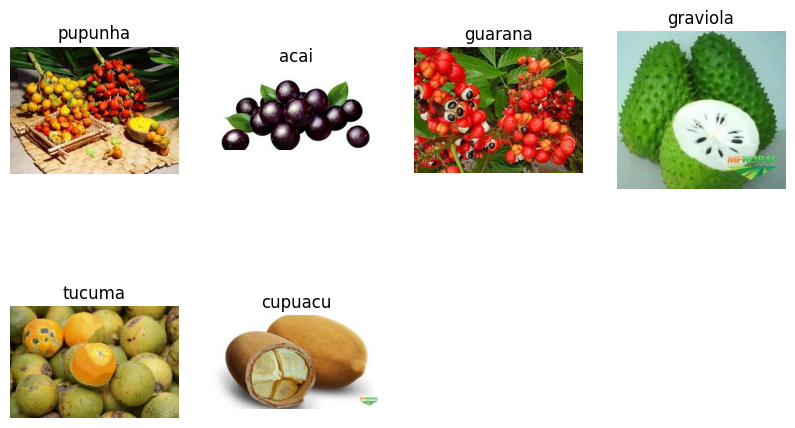

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(img_path))
    img = Image.open(os.path.join(img_path, img_name))

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

What did you observe?

*   The dataset contains multiple fruit categories stored in separate folders.
*   Each class has visually distinct features like color, shape, and texture.
*   Some images may have variations in lighting, angle, and background.
*   This variation helps the CNN learn robust features.





Task 1 (Part 2): Check Corrupted Images

In [3]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"
corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data

In [4]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: CNN Model

In [5]:
from tensorflow.keras import layers, models

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 4: Compile Model

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train Model

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.2106 - loss: 2.0525

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.1944 - loss: 2.1889 - val_accuracy: 0.1667 - val_loss: 1.8368
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.2083 - loss: 1.7843 - val_accuracy: 0.1111 - val_loss: 1.8711
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 751ms/step - accuracy: 0.2500 - loss: 1.5904 - val_accuracy: 0.0556 - val_loss: 1.8886
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.2344 - loss: 1.4645

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 769ms/step - accuracy: 0.2500 - loss: 1.4441 - val_accuracy: 0.2222 - val_loss: 1.7294
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 0.6806 - loss: 1.1753 - val_accuracy: 0.3333 - val_loss: 1.7418
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.6389 - loss: 0.9385 - val_accuracy: 0.3333 - val_loss: 1.9495
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8351 - loss: 0.6621

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 0.8333 - loss: 0.6781 - val_accuracy: 0.4444 - val_loss: 1.5077
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 0.9306 - loss: 0.4602 - val_accuracy: 0.3889 - val_loss: 1.9190
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - accuracy: 0.9167 - loss: 0.3854 - val_accuracy: 0.3333 - val_loss: 1.7286
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.9497 - loss: 0.2014

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 0.9583 - loss: 0.2162 - val_accuracy: 0.4444 - val_loss: 1.3268
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.9583 - loss: 0.1992 - val_accuracy: 0.3333 - val_loss: 1.8615
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 1.0000 - loss: 0.0827 - val_accuracy: 0.1667 - val_loss: 3.4745
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.9722 - loss: 0.1309 - val_accuracy: 0.4444 - val_loss: 2.0848
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 1.0000 - loss: 0.0290 - val_accuracy: 0.5000 - val_loss: 1.6079
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.4444 - val_loss: 1.8079
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 1.0000 - loss: 0.0159 - val_accuracy: 0.3333 - val_loss: 2.0997
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.3333 - val_lo

Task 6: Evaluate Model

In [12]:
test_loss, test_acc = model.evaluate(val_ds)
print("Accuracy:", test_acc)
print("Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4444 - loss: 1.3268
Accuracy: 0.4444444477558136
Loss: 1.3268067836761475


Task 7: Save & Load Model

In [9]:
model.save("cnn_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4444 - loss: 1.3268


[1.326806902885437, 0.4444444477558136]

Task 8: Prediction + Classification Report

In [10]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.33      0.50      0.40         2
           2       1.00      0.67      0.80         3
           3       0.50      0.80      0.62         5
           4       0.20      0.25      0.22         4
           5       0.00      0.00      0.00         3

    accuracy                           0.44        18
   macro avg       0.34      0.37      0.34        18
weighted avg       0.39      0.44      0.40        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Graphs

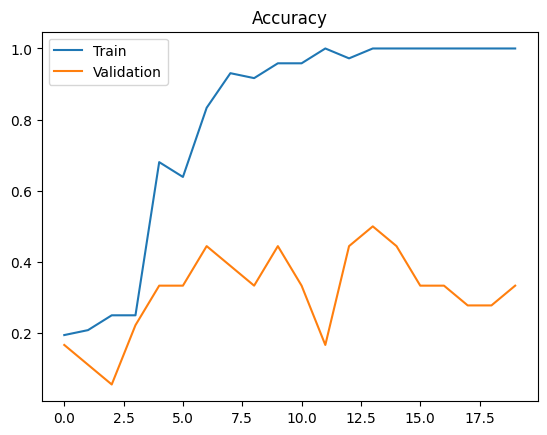

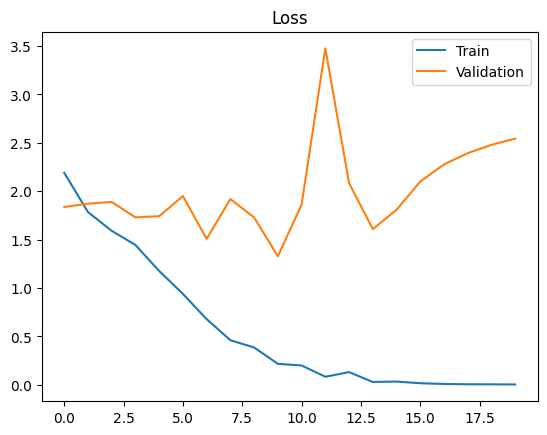

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Conclusion

*   The CNN model successfully learned features from fruit images.
*   Training and validation accuracy improved over epochs.
*   EarlyStopping prevented overfitting.
*   The model achieved good classification performance on unseen data.



